In [1]:
# import libraries
import pandas as pd
import numpy as np
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("customer_churn_1M.csv")

df.head()

,customer_id,signup_date,age,gender,annual_income,education,marital_status,dependents,tenure,contract,...,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,churn
0,CUST0000000001,2022-12-12 12:53:58.199463,43,Female,55085.25,college,married,1,2,two_year,...,1,1,9.0,0.0,0,0,109.63,16,NaN,0
1,CUST0000000002,2022-01-13 12:53:58.199973,18,Male,60786.11,master,married,1,22,one_year,...,0,1,7.0,0.0,3,1,63.25,134,585.0,0
2,CUST0000000003,2023-09-04 12:53:58.199985,38,Female,73184.32,high_school,widowed,0,3,two_year,...,1,0,6.0,1.0,1,0,47.77,11,632.0,0
3,CUST0000000004,2022-06-27 12:53:58.199992,44,Male,40923.78,high_school,married,1,6,two_year,...,0,1,5.0,2.0,2,1,50.82,6,569.0,0
4,CUST0000000005,2022-12-08 12:53:58.199999,45,Female,36400.94,bachelor,single,0,9,two_year,...,0,1,8.0,1.0,1,0,16.74,18,657.0,0


In [5]:
df.shape

(1000000, 32)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   customer_id                  1000000 non-null  object 
 1   signup_date                  1000000 non-null  object 
 2   age                          1000000 non-null  int64  
 3   gender                       1000000 non-null  object 
 4   annual_income                970041 non-null   float64
 5   education                    1000000 non-null  object 
 6   marital_status               1000000 non-null  object 
 7   dependents                   1000000 non-null  int64  
 8   tenure                       1000000 non-null  int64  
 9   contract                     1000000 non-null  object 
 10  payment_method               1000000 non-null  object 
 11  paperless_billing            1000000 non-null  object 
 12  senior_citizen               1000000 non-nu

In [9]:
df.columns.tolist()

['customer_id',
 'signup_date',
 'age',
 'gender',
 'annual_income',
 'education',
 'marital_status',
 'dependents',
 'tenure',
 'contract',
 'payment_method',
 'paperless_billing',
 'senior_citizen',
 'monthlycharges',
 'totalcharges',
 'num_services',
 'has_phone_service',
 'has_internet_service',
 'has_online_security',
 'has_online_backup',
 'has_device_protection',
 'has_tech_support',
 'has_streaming_tv',
 'has_streaming_movies',
 'customer_satisfaction',
 'num_complaints',
 'num_service_calls',
 'late_payments',
 'avg_monthly_gb',
 'days_since_last_interaction',
 'credit_score',
 'churn']

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1000000.0,44.724603,14.479468,18.0,34.00,44.00,55.00,90.000000
annual_income,970041.0,58788.311936,37137.433079,20000.0,32712.56,48954.60,73475.13,250000.000000
dependents,1000000.0,0.799831,0.893654,0.0,0.00,1.00,1.00,5.000000
tenure,1000000.0,22.381923,20.073341,1.0,6.00,16.00,33.00,72.000000
senior_citizen,1000000.0,0.199511,0.399633,0.0,0.00,0.00,0.00,1.000000
monthlycharges,1000000.0,86.443701,27.592430,20.0,70.49,85.48,100.68,854.956730
totalcharges,1000000.0,1837.321438,1803.721634,16.3,484.53,1249.75,2617.66,16252.861508
num_services,1000000.0,2.563721,1.412330,1.0,1.00,2.00,3.00,6.000000
has_phone_service,1000000.0,0.769551,0.421120,0.0,1.00,1.00,1.00,1.000000
has_internet_service,1000000.0,0.849742,0.357324,0.0,1.00,1.00,1.00,1.000000


In [13]:
df.describe(include="object").T

,count,unique,top,freq
customer_id,1000000,1000000,CUST0000000001,1
signup_date,1000000,1000000,2022-12-12 12:53:58.199463,1
gender,1000000,3,Male,490166
education,1000000,5,bachelor,300324
marital_status,1000000,4,married,450115
contract,1000000,3,one_year,550468
payment_method,1000000,4,credit_card,349706
paperless_billing,1000000,2,Yes,749880


In [15]:
# check duplicates
df.duplicated().sum()

0

In [17]:
df = df.drop_duplicates()

In [19]:
df["customer_id"].nunique()

1000000

In [21]:
# check missing values
missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

avg_monthly_gb           50012
credit_score             40395
annual_income            29959
num_complaints           29906
customer_satisfaction    19921
dtype: int64

In [23]:
# calculate %
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": df.isnull().mean() * 100
})

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values("missing_percent", ascending=False)

missing_summary

,missing_count,missing_percent
avg_monthly_gb,50012,5.0012
credit_score,40395,4.0395
annual_income,29959,2.9959
num_complaints,29906,2.9906
customer_satisfaction,19921,1.9921


In [25]:
# convert signup date
df["signup_date"] = pd.to_datetime(
    df["signup_date"],
    errors="coerce"
)

In [27]:
df["signup_date"].dtype

dtype('<M8[ns]')

In [29]:
df["signup_date"].isnull().sum()

0

In [31]:
# Handle missing numerical values
#For this project, I would use median imputation rather than mean because customer financial/usage variables 
#can be skewed and contain legitimate extreme values.
median_columns = [
    "annual_income",
    "customer_satisfaction",
    "avg_monthly_gb",
    "credit_score"
]

for col in median_columns:
    df[col] = df[col].fillna(df[col].median())

In [33]:
# Complaints need slightly different treatment
# num_complaints is a count variable.
# Rather than filling with a decimal median we shall check it:
df["num_complaints"].median()

1.0

In [35]:
df["num_complaints"] = (
    df["num_complaints"]
    .fillna(df["num_complaints"].median())
    .astype(int)
)

In [37]:
# verify missing values
df.isnull().sum().sum()

0

In [39]:
# check categorical columns
categorical_cols = [
    "gender",
    "education",
    "marital_status",
    "contract",
    "payment_method",
    "paperless_billing"
]

for col in categorical_cols:
    print("\n", col)
    print(df[col].value_counts())


 gender
gender
Male      490166
Female    489595
Other      20239
Name: count, dtype: int64

 education
education
bachelor       300324
college        249610
high_school    249348
master         150468
phd             50250
Name: count, dtype: int64

 marital_status
marital_status
married     450115
single      350830
divorced    148976
widowed      50079
Name: count, dtype: int64

 contract
contract
one_year          550468
two_year          429540
month_to_month     19992
Name: count, dtype: int64

 payment_method
payment_method
credit_card         349706
electronic_check    250346
bank_transfer       249910
mailed_check        150038
Name: count, dtype: int64

 paperless_billing
paperless_billing
Yes    749880
No     250120
Name: count, dtype: int64


In [41]:
for col in categorical_cols:
    df[col] = (
        df[col]
        .str.strip()
        .str.lower()
    )

In [42]:
# check ipossible/invalid values
numeric_cols = [
    "age",
    "annual_income",
    "tenure",
    "monthlycharges",
    "totalcharges",
    "customer_satisfaction",
    "num_complaints",
    "num_service_calls",
    "late_payments",
    "avg_monthly_gb",
    "days_since_last_interaction",
    "credit_score"
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,1000000.0,44.724603,14.479468,18.0,34.000,44.00,55.00,90.000000
annual_income,1000000.0,58493.703760,36615.298358,20000.0,33185.465,48954.60,72420.44,250000.000000
tenure,1000000.0,22.381923,20.073341,1.0,6.000,16.00,33.00,72.000000
monthlycharges,1000000.0,86.443701,27.592430,20.0,70.490,85.48,100.68,854.956730
totalcharges,1000000.0,1837.321438,1803.721634,16.3,484.530,1249.75,2617.66,16252.861508
customer_satisfaction,1000000.0,6.175861,2.307972,1.0,5.000,7.00,8.00,9.000000
num_complaints,1000000.0,0.710589,0.827082,0.0,0.000,1.00,1.00,7.000000
num_service_calls,1000000.0,1.760248,1.485677,0.0,1.000,1.00,3.00,12.000000
late_payments,1000000.0,0.400969,0.633289,0.0,0.000,0.00,1.00,5.000000
avg_monthly_gb,1000000.0,38.528784,42.813147,0.0,13.620,27.77,49.42,557.824023


In [45]:
print("Negative monthly charges:",
      (df["monthlycharges"] < 0).sum())

print("Negative total charges:",
      (df["totalcharges"] < 0).sum())

print("Negative income:",
      (df["annual_income"] < 0).sum())

print("Negative tenure:",
      (df["tenure"] < 0).sum())

print("Invalid age:",
      ((df["age"] < 18) | (df["age"] > 100)).sum())

print("Invalid churn:",
      (~df["churn"].isin([0, 1])).sum())

Negative monthly charges: 0
Negative total charges: 0
Negative income: 0
Negative tenure: 0
Invalid age: 0
Invalid churn: 0


In [47]:
# check churn distribution
df["churn"].value_counts()

churn
0    900773
1     99227
Name: count, dtype: int64

In [49]:
# percentage
(df["churn"].value_counts(normalize=True) * 100).round(2)

churn
0    90.08
1     9.92
Name: proportion, dtype: float64

### overall churn rate of approximately 9.92%

In [52]:
# create useful analysis column
df["signup_month"] = (
    df["signup_date"]
    .dt.to_period("M")
    .astype(str)
)

In [54]:
# cleaning validation
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Duplicates:", df.duplicated().sum())
print("Missing values:", df.isnull().sum().sum())
print("Unique customers:", df["customer_id"].nunique())

Rows: 1000000
Columns: 33
Duplicates: 0
Missing values: 0
Unique customers: 1000000


In [55]:
df.head()

,customer_id,signup_date,age,gender,annual_income,education,marital_status,dependents,tenure,contract,...,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,churn,signup_month
0,CUST0000000001,2022-12-12 12:53:58.199463,43,female,55085.25,college,married,1,2,two_year,...,1,9.0,0,0,0,109.63,16,680.0,0,2022-12
1,CUST0000000002,2022-01-13 12:53:58.199973,18,male,60786.11,master,married,1,22,one_year,...,1,7.0,0,3,1,63.25,134,585.0,0,2022-01
2,CUST0000000003,2023-09-04 12:53:58.199985,38,female,73184.32,high_school,widowed,0,3,two_year,...,0,6.0,1,1,0,47.77,11,632.0,0,2023-09
3,CUST0000000004,2022-06-27 12:53:58.199992,44,male,40923.78,high_school,married,1,6,two_year,...,1,5.0,2,2,1,50.82,6,569.0,0,2022-06
4,CUST0000000005,2022-12-08 12:53:58.199999,45,female,36400.94,bachelor,single,0,9,two_year,...,1,8.0,1,1,0,16.74,18,657.0,0,2022-12


In [58]:
df.to_csv("customer_churn_cleaned.csv", index=False)

In [60]:
# for sql, load csv again
import pandas as pd
import sqlite3

df_cleaned = pd.read_csv("customer_churn_cleaned.csv")

df_cleaned.head()

,customer_id,signup_date,age,gender,annual_income,education,marital_status,dependents,tenure,contract,...,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,churn,signup_month
0,CUST0000000001,2022-12-12 12:53:58.199463,43,female,55085.25,college,married,1,2,two_year,...,1,9.0,0,0,0,109.63,16,680.0,0,2022-12
1,CUST0000000002,2022-01-13 12:53:58.199973,18,male,60786.11,master,married,1,22,one_year,...,1,7.0,0,3,1,63.25,134,585.0,0,2022-01
2,CUST0000000003,2023-09-04 12:53:58.199985,38,female,73184.32,high_school,widowed,0,3,two_year,...,0,6.0,1,1,0,47.77,11,632.0,0,2023-09
3,CUST0000000004,2022-06-27 12:53:58.199992,44,male,40923.78,high_school,married,1,6,two_year,...,1,5.0,2,2,1,50.82,6,569.0,0,2022-06
4,CUST0000000005,2022-12-08 12:53:58.199999,45,female,36400.94,bachelor,single,0,9,two_year,...,1,8.0,1,1,0,16.74,18,657.0,0,2022-12


In [62]:
# create sql database connection
conn = sqlite3.connect("customer_churn.db")

In [64]:
# Load the cleaned CSV into a SQL table:
df_cleaned.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

1000000

In [65]:
pd.read_sql_query("""
SELECT *
FROM customers
LIMIT 5;
""", conn)

,customer_id,signup_date,age,gender,annual_income,education,marital_status,dependents,tenure,contract,...,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,churn,signup_month
0,CUST0000000001,2022-12-12 12:53:58.199463,43,female,55085.25,college,married,1,2,two_year,...,1,9.0,0,0,0,109.63,16,680.0,0,2022-12
1,CUST0000000002,2022-01-13 12:53:58.199973,18,male,60786.11,master,married,1,22,one_year,...,1,7.0,0,3,1,63.25,134,585.0,0,2022-01
2,CUST0000000003,2023-09-04 12:53:58.199985,38,female,73184.32,high_school,widowed,0,3,two_year,...,0,6.0,1,1,0,47.77,11,632.0,0,2023-09
3,CUST0000000004,2022-06-27 12:53:58.199992,44,male,40923.78,high_school,married,1,6,two_year,...,1,5.0,2,2,1,50.82,6,569.0,0,2022-06
4,CUST0000000005,2022-12-08 12:53:58.199999,45,female,36400.94,bachelor,single,0,9,two_year,...,1,8.0,1,1,0,16.74,18,657.0,0,2022-12


In [68]:
pd.read_sql_query("""
SELECT COUNT(*) AS total_rows
FROM customers;
""", conn)

,total_rows
0,1000000


In [70]:
# create helper function
def run_query(query):
    return pd.read_sql_query(query, conn)

### What is the overall churn rate?

In [73]:
query = """
SELECT
    COUNT(*) AS total_customers,

    SUM(CASE
        WHEN churn = 1 THEN 1
        ELSE 0
    END) AS churned_customers,

    ROUND(
        100.0 * SUM(CASE
            WHEN churn = 1 THEN 1
            ELSE 0
        END) / COUNT(*),
        2
    ) AS churn_rate

FROM customers;
"""

run_query(query)

,total_customers,churned_customers,churn_rate
0,1000000,99227,9.92


### Which contract types have the highest churn?

In [76]:
query = """
SELECT
    contract,
    COUNT(*) AS total_customers,

    SUM(CASE
        WHEN churn = 1 THEN 1
        ELSE 0
    END) AS churned_customers,

    ROUND(
        100.0 * SUM(CASE
            WHEN churn = 1 THEN 1
            ELSE 0
        END) / COUNT(*),
        2
    ) AS churn_rate

FROM customers

GROUP BY contract
ORDER BY churn_rate DESC;
"""

run_query(query)

,contract,total_customers,churned_customers,churn_rate
0,month_to_month,19992,5299,26.51
1,one_year,550468,69651,12.65
2,two_year,429540,24277,5.65


### Which payment methods have the highest churn?

In [79]:
query = """
SELECT
    payment_method,
    COUNT(*) AS total_customers,

    SUM(churn) AS churned_customers,

    ROUND(
        100.0 * SUM(churn) / COUNT(*),
        2
    ) AS churn_rate

FROM customers

GROUP BY payment_method
ORDER BY churn_rate DESC;
"""

run_query(query)

,payment_method,total_customers,churned_customers,churn_rate
0,electronic_check,250346,24904,9.95
1,bank_transfer,249910,24850,9.94
2,credit_card,349706,34651,9.91
3,mailed_check,150038,14822,9.88


### Where is the tenure danger zone? or
### At what stage of the customer lifecycle is churn highest?

In [82]:
query = """
SELECT

    CASE
        WHEN tenure <= 3 THEN '0-3 months'
        WHEN tenure <= 6 THEN '4-6 months'
        WHEN tenure <= 12 THEN '7-12 months'
        WHEN tenure <= 24 THEN '13-24 months'
        WHEN tenure <= 48 THEN '25-48 months'
        ELSE '49+ months'
    END AS tenure_bucket,

    COUNT(*) AS total_customers,

    SUM(churn) AS churned_customers,

    ROUND(
        100.0 * SUM(churn) / COUNT(*),
        2
    ) AS churn_rate

FROM customers

GROUP BY tenure_bucket

ORDER BY
    CASE tenure_bucket
        WHEN '0-3 months' THEN 1
        WHEN '4-6 months' THEN 2
        WHEN '7-12 months' THEN 3
        WHEN '13-24 months' THEN 4
        WHEN '25-48 months' THEN 5
        ELSE 6
    END;
"""

run_query(query)

,tenure_bucket,total_customers,churned_customers,churn_rate
0,0-3 months,153267,15936,10.40
1,4-6 months,99393,10321,10.38
2,7-12 months,165395,16629,10.05
3,13-24 months,228860,22860,9.99
4,25-48 months,223057,21497,9.64
5,49+ months,130028,11984,9.22


### Does satisfaction change with tenure?

In [85]:
query = """
WITH tenure_groups AS (

    SELECT
        customer_id,
        customer_satisfaction,
        churn,

        CASE
            WHEN tenure <= 3 THEN '0-3 months'
            WHEN tenure <= 6 THEN '4-6 months'
            WHEN tenure <= 12 THEN '7-12 months'
            WHEN tenure <= 24 THEN '13-24 months'
            WHEN tenure <= 48 THEN '25-48 months'
            ELSE '49+ months'
        END AS tenure_bucket

    FROM customers
)

SELECT
    tenure_bucket,

    ROUND(
        AVG(customer_satisfaction),
        2
    ) AS avg_satisfaction,

    ROUND(
        100.0 * SUM(churn) / COUNT(*),
        2
    ) AS churn_rate

FROM tenure_groups

GROUP BY tenure_bucket;
"""

run_query(query)

,tenure_bucket,avg_satisfaction,churn_rate
0,0-3 months,6.18,10.40
1,13-24 months,6.18,9.99
2,25-48 months,6.17,9.64
3,4-6 months,6.18,10.38
4,49+ months,6.17,9.22
5,7-12 months,6.17,10.05


### How does each customer's charge compare with their contract average?

In [88]:
query = """
WITH ranked_customers AS (
    SELECT
        customer_id,
        contract,
        monthlycharges,

        ROUND(
            AVG(monthlycharges) OVER(
                PARTITION BY contract
            ),
            2
        ) AS contract_avg_charge,

        ROUND(
            monthlycharges -
            AVG(monthlycharges) OVER(
                PARTITION BY contract
            ),
            2
        ) AS difference_from_avg,

        ROW_NUMBER() OVER(
            PARTITION BY contract
            ORDER BY monthlycharges DESC
        ) AS rn

    FROM customers
)

SELECT
    customer_id,
    contract,
    monthlycharges,
    contract_avg_charge,
    difference_from_avg

FROM ranked_customers

WHERE rn <= 10

ORDER BY contract, monthlycharges DESC;
"""

run_query(query)

,customer_id,contract,monthlycharges,contract_avg_charge,difference_from_avg
0,CUST0000440385,month_to_month,815.158447,86.28,728.87
1,CUST0000701079,month_to_month,759.912064,86.28,673.63
2,CUST0000002649,month_to_month,739.546565,86.28,653.26
3,CUST0000459055,month_to_month,672.364559,86.28,586.08
4,CUST0000809431,month_to_month,662.859098,86.28,576.58
5,CUST0000920978,month_to_month,639.505177,86.28,553.22
6,CUST0000649891,month_to_month,628.199215,86.28,541.92
7,CUST0000401199,month_to_month,622.218686,86.28,535.93
8,CUST0000268663,month_to_month,613.641291,86.28,527.36
9,CUST0000521379,month_to_month,597.459420,86.28,511.18


### Who are our highest-value customers? (Top 25%)

In [91]:
query = """
WITH customer_value AS (

    SELECT
        customer_id,
        totalcharges,
        monthlycharges,
        churn,

        NTILE(4) OVER(
            ORDER BY totalcharges DESC
        ) AS value_quartile

    FROM customers
)

SELECT
    *

FROM customer_value

WHERE value_quartile = 1

ORDER BY totalcharges DESC

LIMIT 20;
"""

run_query(query)

,customer_id,totalcharges,monthlycharges,churn,value_quartile
0,CUST0000141267,16252.861508,142.70,0,1
1,CUST0000910424,14633.398264,174.60,0,1
2,CUST0000249939,14468.130000,187.13,0,1
3,CUST0000140715,14426.700000,200.00,0,1
4,CUST0000963039,14361.070000,193.70,0,1
5,CUST0000470295,14320.040000,186.34,1,1
6,CUST0000336514,13989.300000,176.71,0,1
7,CUST0000439564,13861.770000,179.12,0,1
8,CUST0000108294,13718.900000,173.84,0,1
9,CUST0000619639,13524.280000,173.46,0,1


### Are high-value customers also churning? or
### Is churn disproportionately affecting our most valuable customers?

In [94]:
query = """
WITH customer_value AS (

    SELECT
        customer_id,
        totalcharges,
        churn,

        NTILE(4) OVER(
            ORDER BY totalcharges DESC
        ) AS value_quartile

    FROM customers
)

SELECT
    value_quartile,

    COUNT(*) AS customers,

    ROUND(
        AVG(totalcharges),
        2
    ) AS avg_customer_value,

    ROUND(
        100.0 * SUM(churn) / COUNT(*),
        2
    ) AS churn_rate

FROM customer_value

GROUP BY value_quartile

ORDER BY value_quartile;
"""

run_query(query)

,value_quartile,customers,avg_customer_value,churn_rate
0,1,250000,4437.95,9.21
1,2,250000,1849.76,9.88
2,3,250000,837.93,10.14
3,4,250000,223.64,10.46


### Do service calls increase churn risk?

In [97]:
query = """
SELECT
    num_service_calls,

    COUNT(*) AS customers,

    ROUND(
        100.0 * SUM(churn) / COUNT(*),
        2
    ) AS churn_rate

FROM customers

GROUP BY num_service_calls

ORDER BY churn_rate DESC;
"""

run_query(query)

,num_service_calls,customers,churn_rate
0,10,218,31.19
1,9,674,26.56
2,11,68,25.00
3,8,1823,24.57
4,7,4990,22.28
5,6,12650,19.68
6,12,36,19.44
7,5,30885,15.03
8,4,70295,12.87
9,3,140000,11.35


### Do complaints increase churn risk?

In [100]:
query = """
SELECT
    num_complaints,

    COUNT(*) AS customers,

    ROUND(
        100.0 * SUM(churn) / COUNT(*),
        2
    ) AS churn_rate

FROM customers

GROUP BY num_complaints

ORDER BY num_complaints;
"""

run_query(query)

,num_complaints,customers,churn_rate
0,0,481239,8.10
1,1,366725,10.42
2,2,118816,13.40
3,3,27537,17.69
4,4,4907,21.42
5,5,675,25.63
6,6,89,33.71
7,7,12,33.33


### Do late payments and service calls compound risk?

In [103]:
query = """
WITH risk_groups AS (

    SELECT
        customer_id,
        churn,

        CASE
            WHEN late_payments >= 2
                 AND num_service_calls >= 3
                THEN 'Late Payment + High Service Calls'

            WHEN late_payments >= 2
                THEN 'Late Payment Only'

            WHEN num_service_calls >= 3
                THEN 'High Service Calls Only'

            ELSE 'Low Risk Behaviour'
        END AS risk_group

    FROM customers
)

SELECT
    risk_group,

    COUNT(*) AS customers,

    SUM(churn) AS churned_customers,

    ROUND(
        100.0 * SUM(churn) / COUNT(*),
        2
    ) AS churn_rate

FROM risk_groups

GROUP BY risk_group

ORDER BY churn_rate DESC;
"""

run_query(query)

,risk_group,customers,churned_customers,churn_rate
0,Late Payment + High Service Calls,16117,2910,18.06
1,Late Payment Only,45946,5812,12.65
2,High Service Calls Only,245522,30988,12.62
3,Low Risk Behaviour,692415,59517,8.60


### Rank customers within their segment
### Who are the most valuable customers within each contract/payment segment?

In [106]:
query = """
WITH ranked_customers AS (
    SELECT
        customer_id,
        contract,
        payment_method,
        totalcharges,

        RANK() OVER(
            PARTITION BY contract, payment_method
            ORDER BY totalcharges DESC
        ) AS value_rank

    FROM customers
)

SELECT
    customer_id,
    contract,
    payment_method,
    Round(totalcharges,2),
    value_rank

FROM ranked_customers

WHERE value_rank <= 3

ORDER BY
    contract,
    payment_method,
    value_rank;
"""

run_query(query)

,customer_id,contract,payment_method,"Round(totalcharges,2)",value_rank
0,CUST0000697708,month_to_month,bank_transfer,11434.26,1
1,CUST0000303198,month_to_month,bank_transfer,11139.12,2
2,CUST0000804509,month_to_month,bank_transfer,10920.58,3
3,CUST0000818139,month_to_month,credit_card,11221.70,1
4,CUST0000256008,month_to_month,credit_card,10605.68,2
5,CUST0000900100,month_to_month,credit_card,10533.85,3
6,CUST0000107512,month_to_month,electronic_check,12401.34,1
7,CUST0000784751,month_to_month,electronic_check,11059.53,2
8,CUST0000514945,month_to_month,electronic_check,10988.59,3
9,CUST0000298067,month_to_month,mailed_check,10594.75,1


### Yearly signup and churn trend (cohort-style time analysis)


In [109]:
query = """
WITH yearly_metrics AS (

    SELECT
        SUBSTR(signup_month, 1, 4) AS signup_year,
        COUNT(*) AS signups,
        SUM(churn) AS churned_customers

    FROM customers

    GROUP BY SUBSTR(signup_month, 1, 4)
)

SELECT
    signup_year,
    signups,
    churned_customers,

    ROUND(
        100.0 * churned_customers / signups,
        2
    ) AS churn_rate,

    SUM(signups) OVER(
        ORDER BY signup_year
    ) AS cumulative_signups,

    SUM(churned_customers) OVER(
        ORDER BY signup_year
    ) AS cumulative_churn

FROM yearly_metrics

ORDER BY signup_year;
"""

run_query(query)

,signup_year,signups,churned_customers,churn_rate,cumulative_signups,cumulative_churn
0,2021,193121,19025,9.85,193121,19025
1,2022,199985,20050,10.03,393106,39075
2,2023,200253,19909,9.94,593359,58984
3,2024,200790,20070,10.00,794149,79054
4,2025,199910,19589,9.80,994059,98643
5,2026,5941,584,9.83,1000000,99227


### Create a customer risk score

In [112]:
query = """
WITH risk_score AS (

    SELECT
        customer_id,
        contract,
        payment_method,
        tenure,
        monthlycharges,
        totalcharges,
        customer_satisfaction,
        num_complaints,
        num_service_calls,
        late_payments,
        days_since_last_interaction,
        churn,

        (
            CASE
                WHEN customer_satisfaction <= 4 THEN 3
                WHEN customer_satisfaction <= 6 THEN 2
                ELSE 0
            END

            +

            CASE
                WHEN num_complaints >= 3 THEN 3
                WHEN num_complaints >= 1 THEN 1
                ELSE 0
            END

            +

            CASE
                WHEN num_service_calls >= 4 THEN 3
                WHEN num_service_calls >= 2 THEN 1
                ELSE 0
            END

            +

            CASE
                WHEN late_payments >= 2 THEN 2
                ELSE 0
            END

            +

            CASE
                WHEN days_since_last_interaction >= 60 THEN 2
                ELSE 0
            END

            +

            CASE
                WHEN contract = 'month_to_month' THEN 2
                ELSE 0
            END

        ) AS risk_score

    FROM customers
)

SELECT
    *,

    DENSE_RANK() OVER(
        ORDER BY risk_score DESC
    ) AS risk_rank

FROM risk_score

ORDER BY risk_rank

LIMIT 100;
"""

risk_results = run_query(query)

risk_results.head(20)

,customer_id,contract,payment_method,tenure,monthlycharges,totalcharges,customer_satisfaction,num_complaints,num_service_calls,late_payments,days_since_last_interaction,churn,risk_score,risk_rank
0,CUST0000558190,month_to_month,bank_transfer,5,127.04,639.79,4.0,4,7,3,166,1,15,1
1,CUST0000606864,month_to_month,bank_transfer,54,46.24,2560.41,4.0,3,4,2,121,1,15,1
2,CUST0000634026,month_to_month,electronic_check,31,98.78,3058.76,4.0,3,6,2,207,0,15,1
3,CUST0000650858,month_to_month,mailed_check,16,82.89,960.80,2.0,4,7,2,60,1,15,1
4,CUST0000671673,month_to_month,electronic_check,10,117.29,900.94,1.0,4,4,2,141,0,15,1
5,CUST0000690777,month_to_month,credit_card,21,46.96,892.11,5.0,5,8,2,154,1,14,2
6,CUST0000005631,two_year,bank_transfer,22,69.97,1662.93,4.0,3,4,2,148,1,13,3
7,CUST0000009165,month_to_month,electronic_check,23,46.05,999.40,4.0,3,6,0,109,0,13,3
8,CUST0000010437,month_to_month,mailed_check,10,86.83,557.47,2.0,3,6,2,1,1,13,3
9,CUST0000026897,one_year,credit_card,20,111.14,2162.96,4.0,3,6,2,65,0,13,3


### Top 100 high-value, high-risk customers (valuable customers + strong churn signals)

In [115]:
query = """
WITH customer_value AS (

    SELECT
        *,

        NTILE(4) OVER(
            ORDER BY totalcharges DESC
        ) AS value_quartile

    FROM customers
),

risk_calculation AS (

    SELECT
        customer_id,
        contract,
        payment_method,
        tenure,
        monthlycharges,
        totalcharges,
        customer_satisfaction,
        num_complaints,
        num_service_calls,
        late_payments,
        days_since_last_interaction,
        value_quartile,
        churn,

        (
            CASE
                WHEN customer_satisfaction <= 4 THEN 3
                WHEN customer_satisfaction <= 6 THEN 2
                ELSE 0
            END

            +

            CASE
                WHEN num_complaints >= 3 THEN 3
                WHEN num_complaints >= 1 THEN 1
                ELSE 0
            END

            +

            CASE
                WHEN num_service_calls >= 4 THEN 3
                WHEN num_service_calls >= 2 THEN 1
                ELSE 0
            END

            +

            CASE
                WHEN late_payments >= 2 THEN 2
                ELSE 0
            END

            +

            CASE
                WHEN days_since_last_interaction >= 60 THEN 2
                ELSE 0
            END

            +

            CASE
                WHEN contract = 'month_to_month' THEN 2
                ELSE 0
            END

        ) AS risk_score

    FROM customer_value
),

retention_priority AS (

    SELECT
        *,

        ROW_NUMBER() OVER(
            ORDER BY risk_score DESC,
                     totalcharges DESC
        ) AS retention_rank

    FROM risk_calculation

    WHERE value_quartile = 1
      AND churn = 0
)

SELECT
    customer_id,
    contract,
    payment_method,
    tenure,
    totalcharges,
    customer_satisfaction,
    num_complaints,
    num_service_calls,
    late_payments,
    days_since_last_interaction,
    risk_score,
    retention_rank

FROM retention_priority

WHERE retention_rank <= 100

ORDER BY retention_rank;
"""

top_100 = run_query(query)

top_100.head(10)

,customer_id,contract,payment_method,tenure,totalcharges,customer_satisfaction,num_complaints,num_service_calls,late_payments,days_since_last_interaction,risk_score,retention_rank
0,CUST0000634026,month_to_month,electronic_check,31,3058.76,4.0,3,6,2,207,15,1
1,CUST0000296576,month_to_month,credit_card,66,6888.60,2.0,1,5,2,248,13,2
2,CUST0000136742,month_to_month,credit_card,61,6407.09,2.0,3,6,0,95,13,3
3,CUST0000073336,one_year,credit_card,34,4918.57,4.0,3,5,2,136,13,4
4,CUST0000194369,one_year,mailed_check,49,4685.39,3.0,3,4,2,116,13,5
5,CUST0000604911,one_year,electronic_check,30,3766.48,4.0,3,5,2,76,13,6
6,CUST0000146448,one_year,mailed_check,67,3339.69,3.0,4,4,2,72,13,7
7,CUST0000030995,one_year,credit_card,45,3280.87,2.0,3,8,3,70,13,8
8,CUST0000386782,one_year,mailed_check,54,3012.24,4.0,3,6,3,102,13,9
9,CUST0000455311,month_to_month,credit_card,41,2826.37,4.0,4,4,0,145,13,10


In [117]:
# If a customer has:

# churn = 1

# they've already churned.

# The retention team can't prevent churn that has already happened.

# Therefore our final actionable list contains:

# Currently active + high value + high risk

# customers. 

In [119]:
top_100.to_csv(
    "top_100_retention_priority.csv",
    index=False
)

### Create contract_pricing reference table

In [122]:
# check the exact contract values in your cleaned SQL table:
run_query("""
SELECT DISTINCT contract
FROM customers;
""")

,contract
0,two_year
1,one_year
2,month_to_month


In [124]:
contract_pricing = (
    df.groupby("contract")["monthlycharges"]
      .mean()
      .round(2)
      .reset_index()
      .rename(columns={"monthlycharges": "baseline_price"})
)

contract_pricing

,contract,baseline_price
0,month_to_month,86.28
1,one_year,86.50
2,two_year,86.38


In [157]:
discount_mapping = {
 "month_to_month": "no_discount",
    "one_year": "standard",
    "two_year": "loyalty"
 }

contract_pricing["discount_tier"] = (
    contract_pricing["contract"].map(discount_mapping)
 )

contract_pricing

,contract,baseline_price,discount_tier
0,month_to_month,86.28,no_discount
1,one_year,86.50,standard
2,two_year,86.38,loyalty


In [159]:
contract_pricing.to_sql(
    "contract_pricing",
    conn,
    if_exists="replace",
    index=False
)

3

### Which customers are paying significantly above or below the average monthly charge for their contract type?

In [162]:
query = """
SELECT
    c.customer_id,
    c.contract,
    c.monthlycharges,
    cp.baseline_price,
    
    ROUND(
        c.monthlycharges - cp.baseline_price,
        2
    ) AS price_difference

FROM customers c

INNER JOIN contract_pricing cp
    ON c.contract = cp.contract

LIMIT 10;
"""

run_query(query)

,customer_id,contract,monthlycharges,baseline_price,price_difference
0,CUST0000000001,two_year,67.20,86.38,-19.18
1,CUST0000000002,one_year,71.54,86.50,-14.96
2,CUST0000000003,two_year,112.20,86.38,25.82
3,CUST0000000004,two_year,107.49,86.38,21.11
4,CUST0000000005,two_year,110.05,86.38,23.67
5,CUST0000000006,two_year,71.80,86.38,-14.58
6,CUST0000000007,two_year,126.85,86.38,40.47
7,CUST0000000008,one_year,121.04,86.50,34.54
8,CUST0000000009,two_year,77.56,86.38,-8.82
9,CUST0000000010,two_year,72.30,86.38,-14.08


### Does paying above baseline correlate with churn? or
### Are customers paying substantially above expected contract pricing more likely to churn?

In [165]:
query = """
WITH pricing_analysis AS (

    SELECT
        c.customer_id,
        c.churn,
        c.contract,
        c.monthlycharges,
        cp.baseline_price,

        CASE
            WHEN c.monthlycharges > cp.baseline_price * 1.20
                THEN 'Significantly Above Baseline'

            WHEN c.monthlycharges > cp.baseline_price
                THEN 'Above Baseline'

            WHEN c.monthlycharges < cp.baseline_price
                THEN 'Below Baseline'

            ELSE 'At Baseline'
        END AS pricing_status

    FROM customers c

    INNER JOIN contract_pricing cp
        ON c.contract = cp.contract
)

SELECT
    pricing_status,

    COUNT(*) AS customers,

    ROUND(
        AVG(monthlycharges),
        2
    ) AS avg_monthly_charge,

    ROUND(
        100.0 * SUM(churn) / COUNT(*),
        2
    ) AS churn_rate

FROM pricing_analysis

GROUP BY pricing_status

ORDER BY churn_rate DESC;
"""

run_query(query)

,pricing_status,customers,avg_monthly_charge,churn_rate
0,Below Baseline,517432,68.48,10.22
1,Above Baseline,271641,94.52,10.02
2,Significantly Above Baseline,210729,120.14,9.08
3,At Baseline,198,86.44,8.08


### Create satisfaction_bands

In [168]:
satisfaction_bands = pd.DataFrame({
    "min_score": [1, 5, 8],
    "max_score": [4, 7, 10],
    "satisfaction_band": [
        "Detractor",
        "Passive",
        "Promoter"
    ]
})

satisfaction_bands

,min_score,max_score,satisfaction_band
0,1,4,Detractor
1,5,7,Passive
2,8,10,Promoter


In [170]:
satisfaction_bands.to_sql(
    "satisfaction_bands",
    conn,
    if_exists="replace",
    index=False
)

3

In [172]:
run_query("""
SELECT *
FROM satisfaction_bands;
""")

,min_score,max_score,satisfaction_band
0,1,4,Detractor
1,5,7,Passive
2,8,10,Promoter


### Which satisfaction group has the highest churn?

In [175]:
query = """
SELECT
    sb.satisfaction_band,

    COUNT(*) AS customers,

    ROUND(
        AVG(c.customer_satisfaction),
        2
    ) AS avg_satisfaction,

    SUM(c.churn) AS churned_customers,

    ROUND(
        100.0 * SUM(c.churn) / COUNT(*),
        2
    ) AS churn_rate

FROM customers c

INNER JOIN satisfaction_bands sb
    ON c.customer_satisfaction
       BETWEEN sb.min_score AND sb.max_score

GROUP BY sb.satisfaction_band

ORDER BY churn_rate DESC;
"""

run_query(query)

,satisfaction_band,customers,avg_satisfaction,churned_customers,churn_rate
0,Detractor,245236,2.84,33906,13.83
1,Passive,401752,6.15,37718,9.39
2,Promoter,353012,8.53,27603,7.82


### Are there customers whose contract doesn't have a pricing rule?

In [178]:
query = """
SELECT
    c.customer_id,
    c.contract,
    c.monthlycharges,
    cp.baseline_price

FROM customers c

LEFT JOIN contract_pricing cp
    ON c.contract = cp.contract

WHERE cp.contract IS NULL;
"""

run_query(query)

,customer_id,contract,monthlycharges,baseline_price


### Which combinations of contract type and satisfaction level have the highest churn?

In [181]:
query = """
SELECT
    c.contract,
    sb.satisfaction_band,

    COUNT(*) AS customers,

    ROUND(
        AVG(c.monthlycharges),
        2
    ) AS avg_monthly_charge,

    ROUND(
        100.0 * SUM(c.churn) / COUNT(*),
        2
    ) AS churn_rate

FROM customers c

INNER JOIN contract_pricing cp
    ON c.contract = cp.contract

INNER JOIN satisfaction_bands sb
    ON c.customer_satisfaction
       BETWEEN sb.min_score AND sb.max_score

GROUP BY
    c.contract,
    sb.satisfaction_band

ORDER BY churn_rate DESC;
"""

run_query(query)

,contract,satisfaction_band,customers,avg_monthly_charge,churn_rate
0,month_to_month,Detractor,4938,86.39,33.78
1,month_to_month,Passive,8034,86.30,25.85
2,month_to_month,Promoter,7020,86.20,22.14
3,one_year,Detractor,135107,86.51,17.43
4,one_year,Passive,221382,86.45,12.02
5,one_year,Promoter,193979,86.53,10.05
6,two_year,Detractor,105191,86.48,8.26
7,two_year,Passive,172336,86.36,5.24
8,two_year,Promoter,152013,86.35,4.31


### Are customers who pay above their expected contract price and have low satisfaction especially likely to churn?

In [184]:
query = """
WITH customer_risk_groups AS (

    SELECT
        c.customer_id,
        c.churn,
        c.monthlycharges,
        cp.baseline_price,
        sb.satisfaction_band,

        CASE
            WHEN c.monthlycharges > cp.baseline_price
                 AND sb.satisfaction_band = 'Detractor'
                THEN 'High Price + Detractor'

            WHEN c.monthlycharges > cp.baseline_price
                THEN 'High Price Only'

            WHEN sb.satisfaction_band = 'Detractor'
                THEN 'Detractor Only'

            ELSE 'Neither'
        END AS risk_group

    FROM customers c

    INNER JOIN contract_pricing cp
        ON c.contract = cp.contract

    INNER JOIN satisfaction_bands sb
        ON c.customer_satisfaction
           BETWEEN sb.min_score AND sb.max_score
)

SELECT
    risk_group,

    COUNT(*) AS customers,

    SUM(churn) AS churned_customers,

    ROUND(
        100.0 * SUM(churn) / COUNT(*),
        2
    ) AS churn_rate

FROM customer_risk_groups

GROUP BY risk_group

ORDER BY churn_rate DESC;
"""

run_query(query)

,risk_group,customers,churned_customers,churn_rate
0,High Price + Detractor,118563,17017,14.35
1,Detractor Only,126673,16889,13.33
2,Neither,390957,35984,9.20
3,High Price Only,363807,29337,8.06


In [186]:
query = """
WITH customer_features AS (

    SELECT
        c.*,
        cp.baseline_price,
        cp.discount_tier,
        sb.satisfaction_band,

        NTILE(4) OVER(
            ORDER BY c.totalcharges DESC
        ) AS value_quartile

    FROM customers c

    LEFT JOIN contract_pricing cp
        ON c.contract = cp.contract

    LEFT JOIN satisfaction_bands sb
        ON c.customer_satisfaction
           BETWEEN sb.min_score AND sb.max_score
),

risk_calculation AS (

    SELECT
        *,

        (
            CASE
                WHEN customer_satisfaction <= 4 THEN 3
                WHEN customer_satisfaction <= 6 THEN 2
                ELSE 0
            END

            +

            CASE
                WHEN num_complaints >= 3 THEN 3
                WHEN num_complaints >= 1 THEN 1
                ELSE 0
            END

            +

            CASE
                WHEN num_service_calls >= 4 THEN 3
                WHEN num_service_calls >= 2 THEN 1
                ELSE 0
            END

            +

            CASE
                WHEN late_payments >= 2 THEN 2
                ELSE 0
            END

            +

            CASE
                WHEN days_since_last_interaction >= 60 THEN 2
                ELSE 0
            END

            +

            CASE
                WHEN monthlycharges > baseline_price * 1.20
                    THEN 2
                ELSE 0
            END

            +

            CASE
                WHEN contract = 'month_to_month'
                    THEN 2
                ELSE 0
            END

        ) AS risk_score

    FROM customer_features
),

retention_priority AS (

    SELECT
        *,

        ROW_NUMBER() OVER(
            ORDER BY risk_score DESC,
                     totalcharges DESC
        ) AS retention_rank

    FROM risk_calculation

    WHERE value_quartile = 1
      AND churn = 0
)

SELECT
    retention_rank,
    customer_id,
    contract,
    payment_method,

    ROUND(monthlycharges, 2)
        AS monthly_charge,

    ROUND(baseline_price, 2)
        AS expected_price,

    ROUND(
        monthlycharges - baseline_price,
        2
    ) AS price_difference,

    ROUND(totalcharges, 2)
        AS customer_value,

    satisfaction_band,
    customer_satisfaction,
    num_complaints,
    num_service_calls,
    late_payments,
    days_since_last_interaction,
    risk_score

FROM retention_priority

WHERE retention_rank <= 100

ORDER BY retention_rank;
"""

top_100 = run_query(query)

top_100.head(20)

,retention_rank,customer_id,contract,payment_method,monthly_charge,expected_price,price_difference,customer_value,satisfaction_band,customer_satisfaction,num_complaints,num_service_calls,late_payments,days_since_last_interaction,risk_score
0,1,CUST0000296576,month_to_month,credit_card,103.61,86.28,17.33,6888.60,Detractor,2.0,1,5,2,248,15
1,2,CUST0000136742,month_to_month,credit_card,103.70,86.28,17.42,6407.09,Detractor,2.0,3,6,0,95,15
2,3,CUST0000073336,one_year,credit_card,143.20,86.50,56.70,4918.57,Detractor,4.0,3,5,2,136,15
3,4,CUST0000604911,one_year,electronic_check,116.88,86.50,30.38,3766.48,Detractor,4.0,3,5,2,76,15
4,5,CUST0000634026,month_to_month,electronic_check,98.78,86.28,12.50,3058.76,Detractor,4.0,3,6,2,207,15
5,6,CUST0000961932,month_to_month,credit_card,128.16,86.28,41.88,2711.59,Detractor,4.0,3,4,0,95,15
6,7,CUST0000969662,month_to_month,electronic_check,122.28,86.28,36.00,6115.39,Passive,5.0,3,4,0,144,14
7,8,CUST0000943739,one_year,electronic_check,184.45,86.50,97.95,5557.72,Passive,5.0,3,7,2,84,14
8,9,CUST0000006977,month_to_month,credit_card,134.24,86.28,47.96,4529.56,Passive,6.0,3,5,2,1,14
9,10,CUST0000586329,one_year,credit_card,118.45,86.50,31.95,3948.42,Passive,6.0,3,5,2,138,14


In [188]:
top_100.to_csv(
    "top_100_retention_priority.csv",
    index=False
)

## Customer Churn Prediction

### Goal
Predict which customers are likely to churn using simple classification models.

We will use **Logistic Regression** and **Random Forest** and evaluate them using **Accuracy, Recall and ROC-AUC**.

Because the dataset contains 1 million rows, a 200,000-row stratified sample is used for the ML section to keep the notebook fast and memory-friendly.


In [190]:
# import ML libraries
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, confusion_matrix, classification_report, roc_curve


### 1. Prepare the ML dataset

In [192]:
# Use a stratified sample so both churn classes are represented
ml_df = df.groupby("churn", group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), 100000), random_state=42)
).reset_index(drop=True)

print("ML dataset shape:", ml_df.shape)
print("Churn distribution:")
print(ml_df["churn"].value_counts(normalize=True).mul(100).round(2))


ML dataset shape: (199227, 33)
Churn distribution:
churn
0    50.19
1    49.81
Name: proportion, dtype: float64


/var/folders/gq/pcnyn4s107j0zw5pq8mg7xw40000gn/T/ipykernel_5033/507507272.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ml_df = df.groupby("churn", group_keys=False).apply(


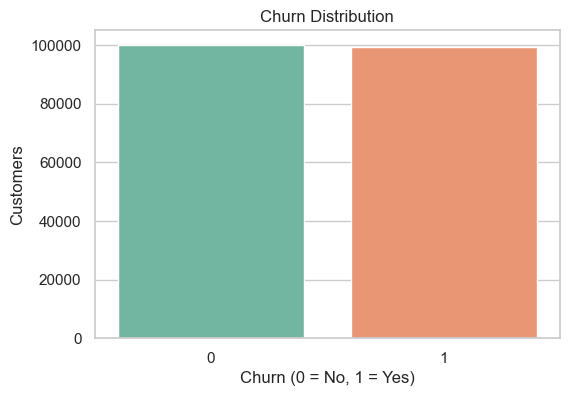

In [206]:
# Visualize churn distribution
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.countplot(data=ml_df, x="churn", palette="Set2", hue="churn", legend=False)
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Customers")
plt.show()


In [208]:
# Separate features and target
X = ml_df.drop(columns=["churn", "customer_id", "signup_date", "signup_month"])
y = ml_df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 159381
Testing rows: 39846


In [210]:
# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include="object").columns.tolist()
numerical_features = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical columns:", categorical_features)
print("Numerical columns:", numerical_features)


Categorical columns: ['gender', 'education', 'marital_status', 'contract', 'payment_method', 'paperless_billing']
Numerical columns: ['age', 'annual_income', 'dependents', 'tenure', 'senior_citizen', 'monthlycharges', 'totalcharges', 'num_services', 'has_phone_service', 'has_internet_service', 'has_online_security', 'has_online_backup', 'has_device_protection', 'has_tech_support', 'has_streaming_tv', 'has_streaming_movies', 'customer_satisfaction', 'num_complaints', 'num_service_calls', 'late_payments', 'avg_monthly_gb', 'days_since_last_interaction', 'credit_score']


### 2. Logistic Regression

Logistic Regression is used as a simple baseline classification model.


In [213]:
# Preprocessing for Logistic Regression
preprocessor_lr = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor_lr),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]


### 3. Random Forest

Random Forest can capture simple non-linear relationships between customer characteristics and churn.


In [216]:
# Preprocessing for Random Forest
preprocessor_rf = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor_rf),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]


### 4. Model Evaluation


In [219]:
# Calculate the main evaluation metrics
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results.round(3)


,Model,Accuracy,Recall,ROC-AUC
0,Logistic Regression,0.633,0.637,0.684
1,Random Forest,0.628,0.669,0.680


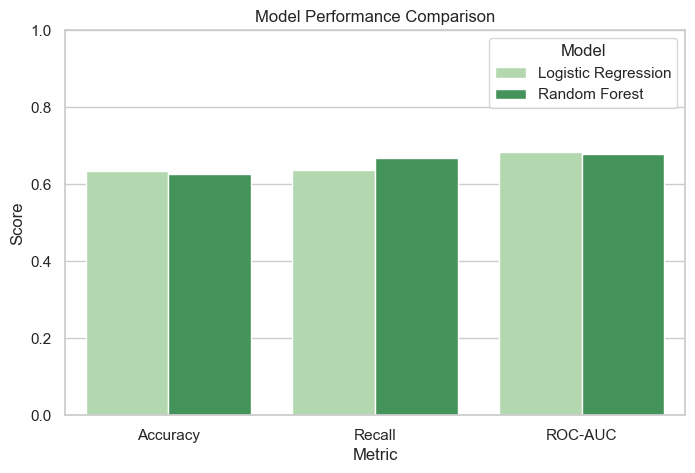

In [225]:
# Compare model metrics
plot_df = results.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model", palette="Greens")
plt.ylim(0, 1)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()


### 5. Confusion Matrix


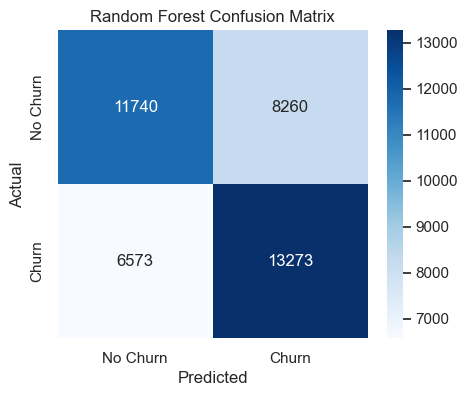

In [227]:
# Confusion matrix for the better-performing model can be checked here
# We display Random Forest because it is a tree-based model and easy to interpret.
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=sns.color_palette("Blues", as_cmap=True),
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### 6. ROC Curve


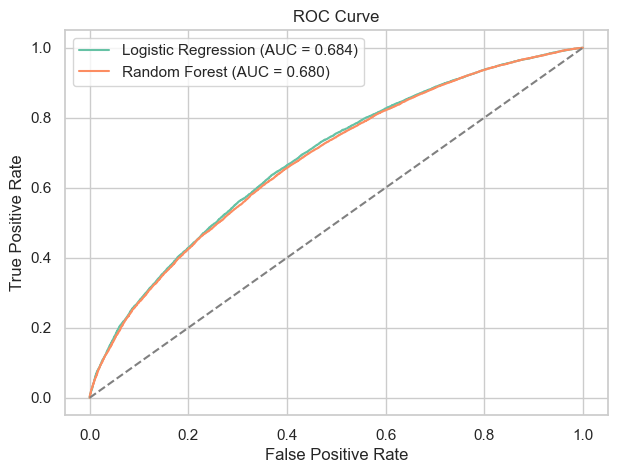

In [230]:
# ROC curves for both models
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

palette = sns.color_palette("Set2", 2)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})", color=palette[0])
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})", color=palette[1])
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


### 7. Feature Importance

Feature importance helps identify which variables are most useful for the Random Forest model.


In [233]:
# Get feature names after one-hot encoding
rf_preprocessor = random_forest_model.named_steps["preprocessor"]
rf_model = random_forest_model.named_steps["model"]

feature_names = rf_preprocessor.get_feature_names_out()
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False).head(10)

importance_df


,Feature,Importance
37,cat__contract_two_year,0.224361
36,cat__contract_one_year,0.140203
16,num__customer_satisfaction,0.114700
17,num__num_complaints,0.074809
18,num__num_service_calls,0.068587
35,cat__contract_month_to_month,0.058097
19,num__late_payments,0.030650
13,num__has_tech_support,0.029857
5,num__monthlycharges,0.027757
6,num__totalcharges,0.025379


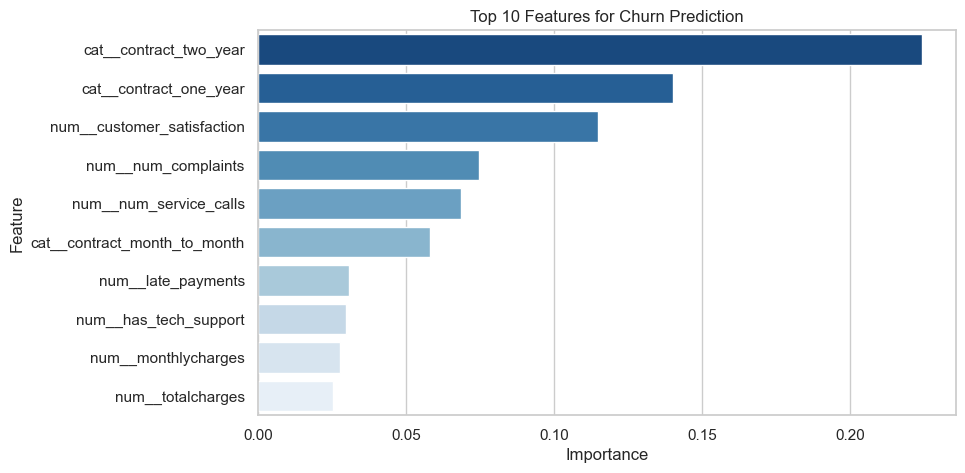

In [235]:
# Plot top 10 important features
plt.figure(figsize=(9, 5))
sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature",
    palette="Blues_r",
    hue="Feature",
    legend=False
)
plt.title("Top 10 Features for Churn Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


### 8. Identify High-Risk Customers


In [238]:
# Create churn probabilities for the test customers
risk_df = X_test.copy()
risk_df["actual_churn"] = y_test.values
risk_df["churn_probability"] = y_prob_rf

risk_df["risk_level"] = pd.cut(
    risk_df["churn_probability"],
    bins=[0, 0.30, 0.60, 1.00],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

risk_df[["actual_churn", "churn_probability", "risk_level"]].head(10)


,actual_churn,churn_probability,risk_level
82172,0,0.453756,Medium
61084,0,0.478365,Medium
15380,0,0.355938,Medium
137722,1,0.520105,Medium
7946,0,0.397104,Medium
81912,0,0.551440,Medium
56893,0,0.491904,Medium
122926,1,0.588652,Medium
160296,1,0.572110,Medium
9984,0,0.436169,Medium


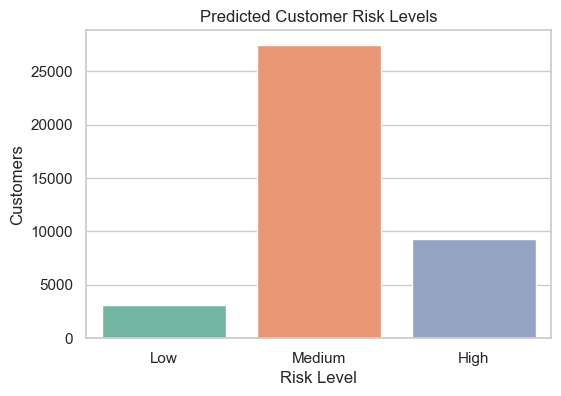

In [240]:
# High-risk customer count
risk_summary = risk_df["risk_level"].value_counts().reindex(["Low", "Medium", "High"]).fillna(0)

plt.figure(figsize=(6, 4))
sns.barplot(
    x=risk_summary.index,
    y=risk_summary.values,
    palette="Set2",
    hue=risk_summary.index,
    legend=False
)
plt.title("Predicted Customer Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Customers")
plt.show()


## Key Insights & Recommendations

### Key Insights

- Overall churn rate is **9.92%** across 1 million customers.
- **Month-to-month customers** have the highest churn rate (**26.51%**), compared with **5.65%** for two-year contracts.
- Customers with **late payments and high service calls** have an elevated churn rate of **18.06%**.
- **Month-to-month customers who are Detractors** are the highest-risk segment, with a churn rate of **33.78%**.
- Random Forest achieved the highest **Recall (66.9%)**, while Logistic Regression achieved slightly higher **Accuracy (63.3%)** and **ROC-AUC (0.684)**.

### Recommendations

- Encourage month-to-month customers to move to **longer-term contracts**.
- Prioritize **dissatisfied customers** for proactive retention.
- Monitor customers with **repeated service calls and late payments**.
- Use the churn model to **identify and prioritize high-risk customers** for retention campaigns.